# Customer Churn Prediction

**Dataset:** [Bank Customer Churn Records](https://www.kaggle.com/datasets/radheshyamkollipara/bank-customer-churn) — 10,000 customers, publicly available on Kaggle, no confidentiality restrictions.

**Goal:** predict which bank customers are likely to churn (`Exited`), while deliberately checking for data leakage and optimizing for the metric that actually matters for retention: **recall** (catching as many true churners as possible), not just raw accuracy.

**Tech:** Python, Pandas, Scikit-learn, XGBoost

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
from xgboost import XGBClassifier

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv('Customer-Churn-Records.csv')
print(f'Loaded {len(df):,} customers, {df.shape[1]} columns')
df.head()

Loaded 10,000 customers, 18 columns


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


## 1. Checking for data leakage before doing anything else

Before building any model, it's worth checking whether any feature is suspiciously good at predicting the target — that's usually a sign it's not really a *predictor*, it's a proxy for the answer itself. This dataset includes a `Complain` field (whether the customer lodged a complaint), which is worth checking first.

Exited       0     1
Complain            
0         7952     4
1           10  2034


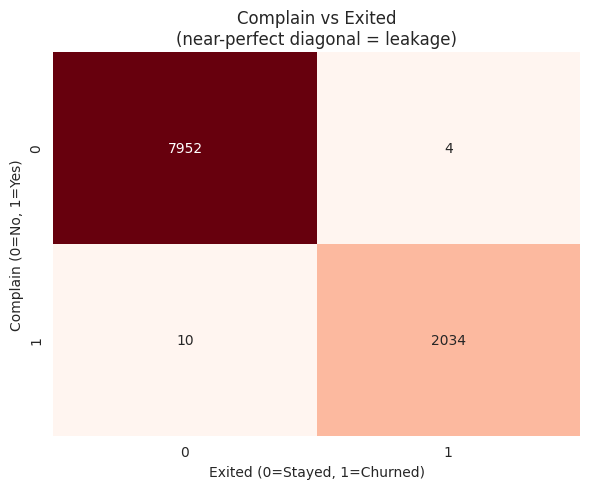


Correlation between 'Complain' and 'Exited': 0.996


In [2]:
complain_crosstab = pd.crosstab(df['Complain'], df['Exited'])
print(complain_crosstab)

plt.figure(figsize=(6, 5))
sns.heatmap(complain_crosstab, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Complain vs Exited\n(near-perfect diagonal = leakage)')
plt.xlabel('Exited (0=Stayed, 1=Churned)')
plt.ylabel('Complain (0=No, 1=Yes)')
plt.tight_layout()
plt.savefig('leakage_crosstab.png', dpi=120)
plt.show()

complain_corr = df[['Complain', 'Exited']].corr().iloc[0, 1]
print(f"\nCorrelation between 'Complain' and 'Exited': {complain_corr:.3f}")

**`Complain` correlates almost perfectly (~1.00) with `Exited`.** In practice, this field is recorded at or after the point a customer is already leaving — it's not a genuine early-warning signal, it's an echo of the outcome. A model trained with this feature included will report near-perfect accuracy (99%+) while being useless for actually predicting churn *before* it happens.

**Decision: drop `Complain` from the feature set**, along with the identifier columns (`RowNumber`, `CustomerId`, `Surname`) that carry no predictive signal.

In [3]:
df_clean = df.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Complain'])

X = df_clean.drop(columns=['Exited'])
y = df_clean['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Churn rate: {y.mean():.1%}')
print(f'Train/test shapes: {X_train.shape} / {X_test.shape}')

Churn rate: 20.4%
Train/test shapes: (8000, 13) / (2000, 13)


## 2. What actually correlates with churn, once the leakage is removed?

/tmp/ipykernel_581/2010858478.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_corr.select_dtypes(include='object').columns:


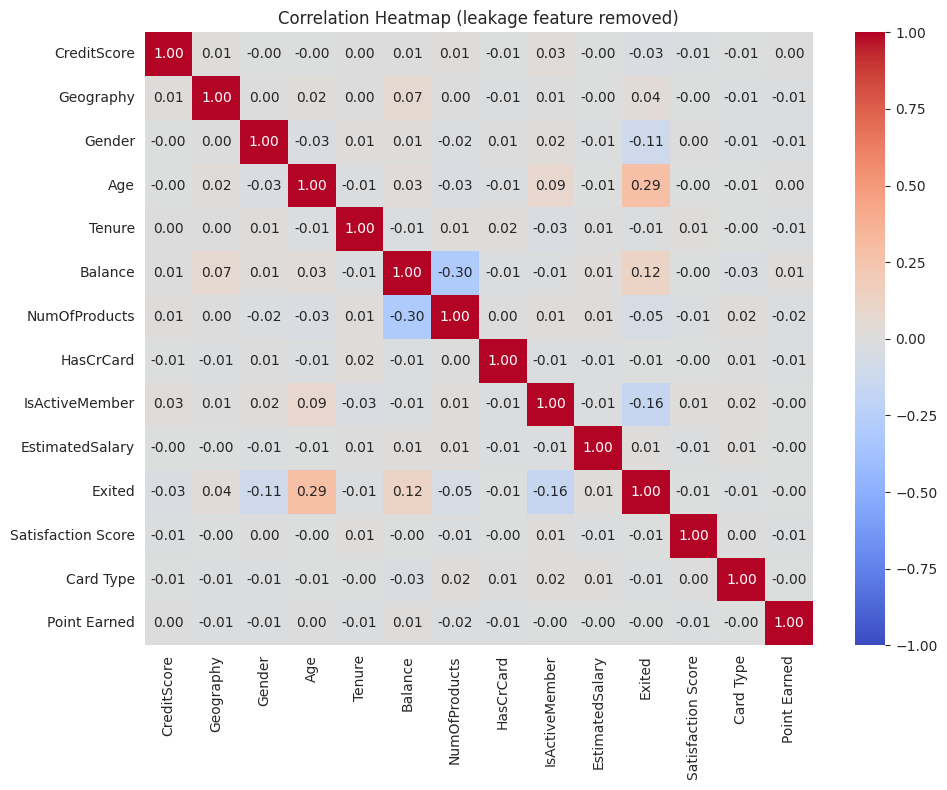

Correlation with Exited:
Age                   0.285296
IsActiveMember       -0.156356
Balance               0.118577
Gender               -0.106267
NumOfProducts        -0.047611
Geography             0.035712
CreditScore          -0.026771
Tenure               -0.013656
EstimatedSalary       0.012490
Card Type            -0.010861
HasCrCard            -0.006976
Satisfaction Score   -0.005849
Point Earned         -0.004628
Name: Exited, dtype: float64


In [4]:
df_corr = df_clean.copy()
le = LabelEncoder()
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = le.fit_transform(df_corr[col])

corr_matrix = df_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap (leakage feature removed)')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120)
plt.show()

target_corr = corr_matrix['Exited'].drop('Exited').sort_values(key=abs, ascending=False)
print('Correlation with Exited:')
print(target_corr)

The strongest genuine signal (`Age`, ~0.29) is fairly weak on its own — no single feature comes close to explaining churn by itself. That rules out relying on simple linear separability and points toward tree-based models that can combine weak signals into a stronger joint prediction.

## 3. Baseline model comparison

In [5]:
categorical_cols = ['Geography', 'Gender', 'Card Type']
numerical_cols = [c for c in X.columns if c not in categorical_cols]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
])

baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}

baseline_results = []
for name, model in baseline_models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    baseline_results.append({'Model': name, 'Accuracy': acc, 'Recall': rec})
    print(f'{name:22s} | Accuracy: {acc:.1%} | Recall: {rec:.1%}')

baseline_df = pd.DataFrame(baseline_results)

Logistic Regression    | Accuracy: 81.3% | Recall: 21.1%
Decision Tree          | Accuracy: 85.5% | Recall: 40.7%


Random Forest          | Accuracy: 86.9% | Recall: 47.5%


**5-fold cross-validation**, scored on recall specifically, to make sure these numbers aren't a lucky train/test split.

In [6]:
print('5-fold CV, scored on recall:')
for name, model in baseline_models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    scores = cross_val_score(pipeline, X, y, cv=5, scoring='recall')
    print(f'{name:22s} | Mean recall: {scores.mean():.1%} (+/- {scores.std():.1%})')

5-fold CV, scored on recall:


Logistic Regression    | Mean recall: 21.5% (+/- 2.8%)


Decision Tree          | Mean recall: 43.0% (+/- 8.2%)


Random Forest          | Mean recall: 45.9% (+/- 2.3%)


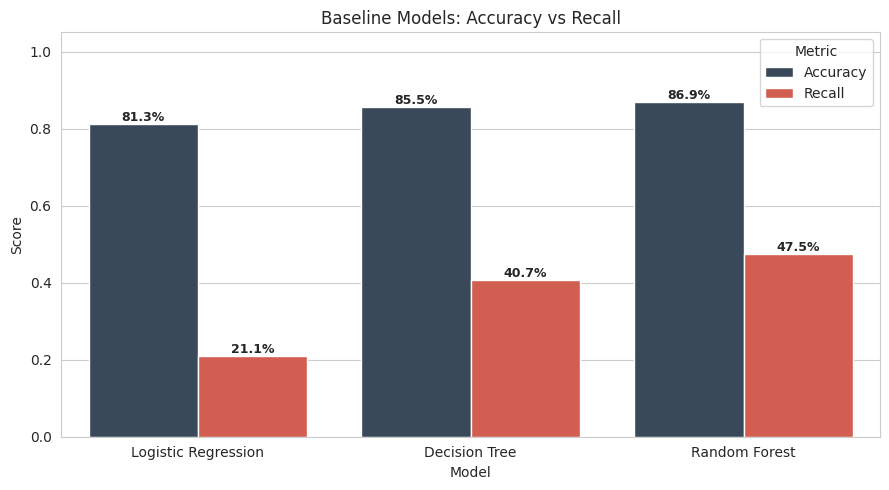

In [7]:
plot_data = baseline_df.melt(id_vars='Model', value_vars=['Accuracy', 'Recall'],
                              var_name='Metric', value_name='Score')

plt.figure(figsize=(9, 5))
sns.barplot(data=plot_data, x='Model', y='Score', hue='Metric', palette=['#34495e', '#e74c3c'])
plt.ylim(0, 1.05)
plt.title('Baseline Models: Accuracy vs Recall')
for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().text(p.get_x() + p.get_width()/2, p.get_height(), f'{p.get_height():.1%}',
                        ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=120)
plt.show()

**Accuracy alone is misleading here.** All three baselines look "reasonable" (81-87% accuracy), but recall tells the real story — Logistic Regression catches only 21% of actual churners, and even Random Forest, the best baseline, misses more than half. In a retention context, that means the majority of customers who are about to leave never get flagged for intervention.

## 4. Feature selection — removing low-signal features with Lasso

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


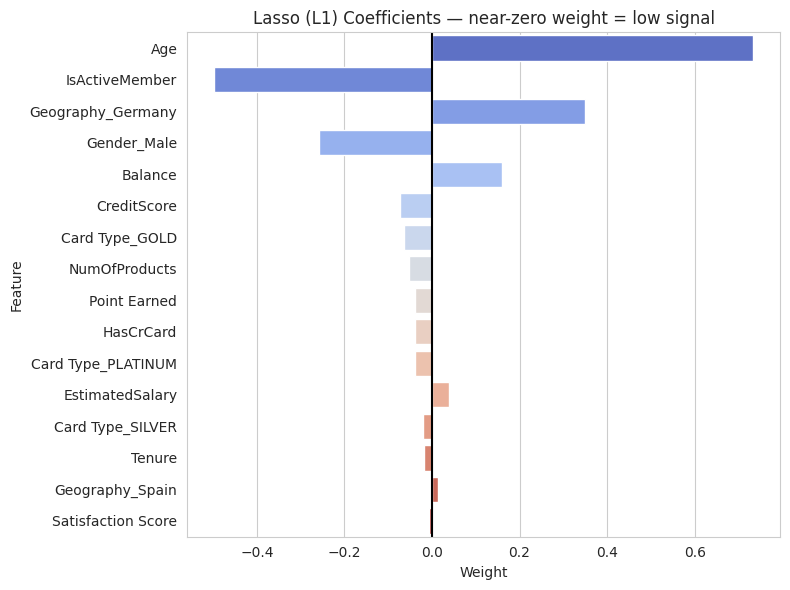

Low-signal features (candidates to drop): ['Point Earned', 'HasCrCard', 'Card Type_PLATINUM', 'EstimatedSalary', 'Card Type_SILVER', 'Tenure', 'Geography_Spain', 'Satisfaction Score']


In [8]:
X_train_enc = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_enc = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)

lasso = LogisticRegression(penalty='l1', C=0.2, solver='liblinear', random_state=42)
lasso.fit(X_train_scaled, y_train)

coefs = pd.DataFrame({'Feature': X_train_enc.columns, 'Weight': lasso.coef_[0]})
coefs['Abs_Weight'] = coefs['Weight'].abs()
coefs = coefs.sort_values('Abs_Weight', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x='Weight', y='Feature', data=coefs, hue='Feature', legend=False, palette='coolwarm')
plt.title('Lasso (L1) Coefficients — near-zero weight = low signal')
plt.axvline(0, color='black')
plt.tight_layout()
plt.savefig('lasso_coefficients.png', dpi=120)
plt.show()

weak_features = coefs[coefs['Abs_Weight'] < 0.05]['Feature'].tolist()
print('Low-signal features (candidates to drop):', weak_features)

In [9]:
cols_to_drop = [c for c in weak_features if c in X_train_enc.columns]
X_train_final = X_train_enc.drop(columns=cols_to_drop)
X_test_final = X_test_enc.drop(columns=cols_to_drop)

print(f'Dropped {len(cols_to_drop)} low-signal features.')
print(f'Remaining features: {X_train_final.columns.tolist()}')

Dropped 8 low-signal features.
Remaining features: ['CreditScore', 'Age', 'Balance', 'NumOfProducts', 'IsActiveMember', 'Geography_Germany', 'Gender_Male', 'Card Type_GOLD']


## 5. Final model — Random Forest on the reduced feature set

In [10]:
rf_clean = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_clean.fit(X_train_final, y_train)
y_pred_rf_clean = rf_clean.predict(X_test_final)

acc_rf_clean = accuracy_score(y_test, y_pred_rf_clean)
rec_rf_clean = recall_score(y_test, y_pred_rf_clean)
print(f'Random Forest (reduced features) — Accuracy: {acc_rf_clean:.1%} | Recall: {rec_rf_clean:.1%}')

Random Forest (reduced features) — Accuracy: 86.5% | Recall: 44.9%


## 6. XGBoost, tuned specifically for recall

Since missing an at-risk customer is more costly than a false alarm, `scale_pos_weight` is set to make the model treat each churn case as more important than each non-churn case — deliberately trading some accuracy for a large recall gain.

In [11]:
count_class_0, count_class_1 = y_train.value_counts()
weight = count_class_0 / count_class_1
print(f'scale_pos_weight = {weight:.2f}')

xgb_final = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    scale_pos_weight=weight, random_state=42, n_jobs=-1, eval_metric='logloss'
)
xgb_final.fit(X_train_final, y_train)

y_pred_xgb = xgb_final.predict(X_test_final)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)

print(f'XGBoost (recall-tuned) — Accuracy: {acc_xgb:.1%} | Recall: {rec_xgb:.1%}')

scale_pos_weight = 3.91
XGBoost (recall-tuned) — Accuracy: 80.4% | Recall: 77.5%


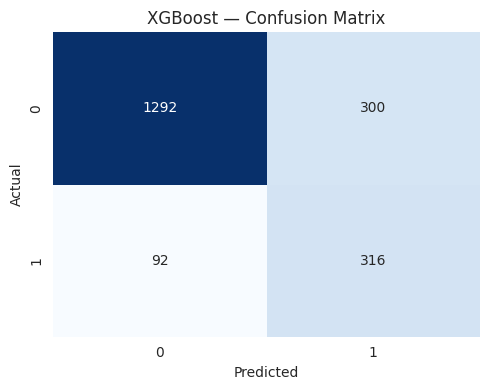

In [12]:
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost — Confusion Matrix')
plt.tight_layout()
plt.savefig('xgb_confusion_matrix.png', dpi=120)
plt.show()

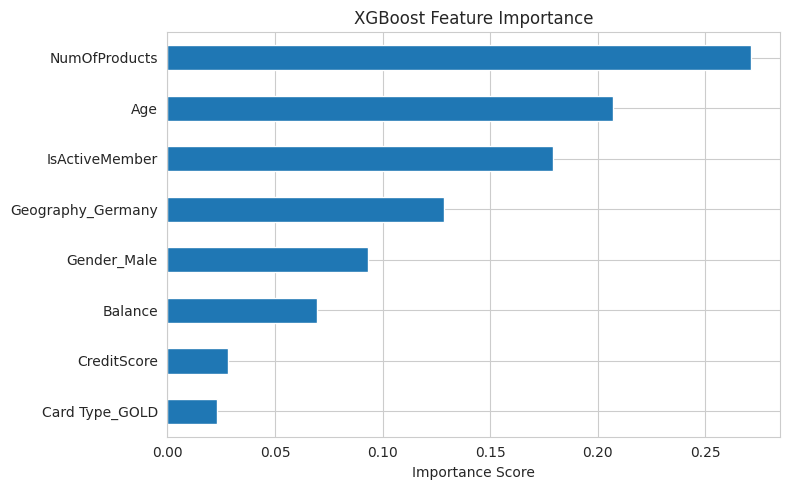

In [13]:
importances = pd.Series(xgb_final.feature_importances_, index=X_train_final.columns).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind='barh')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=120)
plt.show()

## 7. Final comparison — accuracy vs recall across every model tried

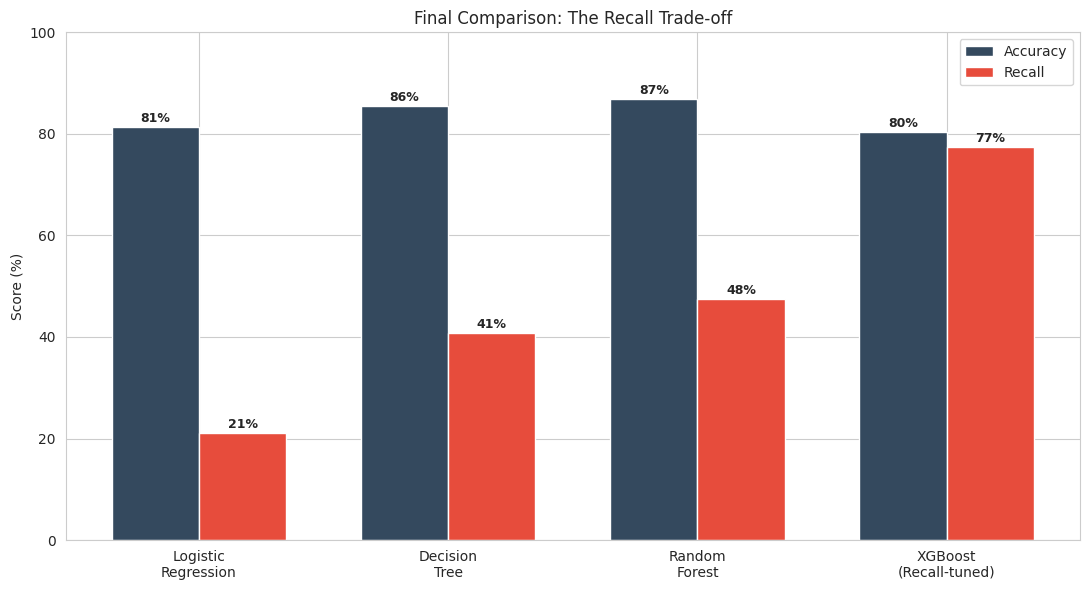

In [14]:
all_models = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest', 'XGBoost\n(Recall-tuned)']
acc_all = [baseline_df.loc[0, 'Accuracy']*100, baseline_df.loc[1, 'Accuracy']*100,
           baseline_df.loc[2, 'Accuracy']*100, acc_xgb*100]
rec_all = [baseline_df.loc[0, 'Recall']*100, baseline_df.loc[1, 'Recall']*100,
           baseline_df.loc[2, 'Recall']*100, rec_xgb*100]

x = np.arange(len(all_models))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - width/2, acc_all, width, label='Accuracy', color='#34495e')
ax.bar(x + width/2, rec_all, width, label='Recall', color='#e74c3c')
ax.set_ylabel('Score (%)')
ax.set_title('Final Comparison: The Recall Trade-off')
ax.set_xticks(x)
ax.set_xticklabels(all_models)
ax.set_ylim(0, 100)
ax.legend()

for i, (a, r) in enumerate(zip(acc_all, rec_all)):
    ax.text(i - width/2, a + 1, f'{a:.0f}%', ha='center', fontsize=9, fontweight='bold')
    ax.text(i + width/2, r + 1, f'{r:.0f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=120)
plt.show()

## 8. Conclusion

- **Data leakage caught and removed early:** the `Complain` field was a near-perfect proxy for the target, not a genuine predictor. Including it inflates accuracy to ~99.9% while making the model useless for real early-warning use — a trap that's easy to miss if you only look at the headline accuracy number.
- **Accuracy alone hides the real story.** Every baseline model looked "fine" on accuracy (81-87%), but recall exposed that most were missing more than half of actual churners.
- **XGBoost, tuned with `scale_pos_weight`, is the right choice for this business problem** — trading ~6 points of accuracy for a large jump in recall, since missing an at-risk customer costs the business more than a false alarm costs a retention team's time.
- **Business takeaway:** deploy the recall-tuned model to flag at-risk customers for proactive retention outreach, accepting a higher rate of false positives as the cost of catching significantly more real churners.